# Covariate Projector + Deep Learning Results

This notebook organizes experiment 2 around three outputs:
- a full combined summary table across all configured rows
- a projector-focused table that isolates which covariate feature sets help the most
- a global comparison bar-chart view that compares all models against one selected projector variant


In [51]:
import sys
from pathlib import Path
import importlib

import pandas as pd
import wandb
from IPython.display import display

REPO_ROOT = Path('/scratch/asr655/neuroinformatics/Conn2Conn')
sys.path.insert(0, str(REPO_ROOT))

import results.results_scraper as rs
importlib.reload(rs)

from results.results_scraper import (
    build_cov_dl_seed_df,
    build_cov_dl_summary_table,
    build_covtype_status_table,
    build_experiment_records,
    build_experiment_records_covtype,
    build_status_table,
    load_records_cache,
    plot_cov_dl_global_metric_panels,
    plot_cov_dl_metric_bars,
    save_records_cache,
)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 200)
pd.set_option('display.width', 240)
pd.set_option('display.float_format', '{:.4f}'.format)

wandb.login()


True

## 1. Experiment Spec

This cell controls:
- which rows appear in the full summary table
- which rows appear in the projector-only table
- which rows appear in the global comparison bar charts


In [52]:
PROJECTOR_MODEL = 'CrossModal_PCA_PLS_CovProjector'
PROJECTOR_SOURCE = 'SC'
PROJECTOR_COV_TYPES = ['demo', 'fs_volumes', 'fs_all', 'fs_all_demo']
BEST_PROJECTOR_COV_TYPE = 'demo'  # used in the step-5 global comparison plot

BASELINE_MODEL = 'CrossModal_PCA_PLS_learnable'
BASELINE_SOURCE = 'SC'

INCLUDE_DEEP_MODELS = True
DEEP_SOURCE = 'SC'

SEEDS = list(range(10))
SELECTION_METRIC = 'val_demeaned_r'
SELECTION_MODE = 'max'

SCRAPE_MODE = 'cache'  # 'cache' or 'rescrape'
SCRAPE_CACHE_PATH = REPO_ROOT / 'results' / 'conn2conn' / 'scrape_cache' / 'cov_dl_records.json'

METRICS = ['pearson', 'demeaned_pearson', 'mse', 'avg_rank', 'top1_acc']
METRIC_LABELS = {
    'pearson': 'corr',
    'demeaned_pearson': 'demeaned_corr',
    'mse': 'mse',
    'avg_rank': 'avg_rank',
    'top1_acc': 'top1_acc',
}

BASELINE_ROW_SPECS = [
    {
        'model': 'Krakencoder_precomputed',
        'source': 'SC',
        'cov_type': None,
        'display_model': 'Krakencoder',
        'sc_source_label': 'SC',
        'cov_source_label': '-',
        'plot_label': 'Krakencoder',
    },
    {
        'model': BASELINE_MODEL,
        'source': BASELINE_SOURCE,
        'cov_type': None,
        'display_model': 'PCA_PLS_learnable',
        'sc_source_label': BASELINE_SOURCE,
        'cov_source_label': '-',
        'plot_label': 'PCA_PLS_learnable',
    },
]

PROJECTOR_ROW_SPECS = [
    {
        'model': PROJECTOR_MODEL,
        'source': PROJECTOR_SOURCE,
        'cov_type': 'demo',
        'display_model': 'PCA_PLS_projector',
        'sc_source_label': PROJECTOR_SOURCE,
        'cov_source_label': 'demo',
        'plot_label': 'PCA_PLS_projector (demo)',
    },
    {
        'model': PROJECTOR_MODEL,
        'source': PROJECTOR_SOURCE,
        'cov_type': 'fs_volumes',
        'display_model': 'PCA_PLS_projector',
        'sc_source_label': PROJECTOR_SOURCE,
        'cov_source_label': 'fs_volumes',
        'plot_label': 'PCA_PLS_projector (fs_volumes)',
    },
    {
        'model': PROJECTOR_MODEL,
        'source': PROJECTOR_SOURCE,
        'cov_type': 'fs_all',
        'display_model': 'PCA_PLS_projector',
        'sc_source_label': PROJECTOR_SOURCE,
        'cov_source_label': 'fs_all',
        'plot_label': 'PCA_PLS_projector (fs_all)',
    },
    {
        'model': PROJECTOR_MODEL,
        'source': PROJECTOR_SOURCE,
        'cov_type': 'fs_all_demo',
        'display_model': 'PCA_PLS_projector',
        'sc_source_label': PROJECTOR_SOURCE,
        'cov_source_label': 'demo+fs_all',
        'plot_label': 'PCA_PLS_projector (demo+fs_all)',
    },
]

DEEP_ROW_SPECS = [
    {
        'model': 'Sarwar2020MLP',
        'source': DEEP_SOURCE,
        'cov_type': None,
        'display_model': 'MLP (Sarwar, 2021)',
        'sc_source_label': DEEP_SOURCE,
        'cov_source_label': '-',
        'plot_label': 'MLP (Sarwar, 2021)',
    },
    {
        'model': 'Chen2024GCN',
        'source': DEEP_SOURCE,
        'cov_type': None,
        'display_model': 'GNN (Chen, 2024)',
        'sc_source_label': DEEP_SOURCE,
        'cov_source_label': '-',
        'plot_label': 'GNN (Chen, 2024)',
    },
    {
        'model': 'NodalGNN',
        'source': DEEP_SOURCE,
        'cov_type': None,
        'display_model': 'Nodal GNN',
        'sc_source_label': DEEP_SOURCE,
        'cov_source_label': '-',
        'plot_label': 'Nodal GNN',
    },
]

FULL_ROW_SPECS = BASELINE_ROW_SPECS + PROJECTOR_ROW_SPECS + (DEEP_ROW_SPECS if INCLUDE_DEEP_MODELS else [])
PROJECTOR_FOCUS_ROW_SPECS = [BASELINE_ROW_SPECS[1]] + PROJECTOR_ROW_SPECS
GLOBAL_COMPARE_ROW_SPECS = [
    BASELINE_ROW_SPECS[0],
    BASELINE_ROW_SPECS[1],
    next(spec for spec in PROJECTOR_ROW_SPECS if spec['cov_type'] == BEST_PROJECTOR_COV_TYPE),
] + (DEEP_ROW_SPECS if INCLUDE_DEEP_MODELS else [])

STANDARD_MODELS = sorted({spec['model'] for spec in FULL_ROW_SPECS if spec.get('cov_type') is None})
STANDARD_SOURCES = sorted({spec['source'] for spec in FULL_ROW_SPECS if spec.get('cov_type') is None})
PROJECTOR_MODELS = sorted({spec['model'] for spec in FULL_ROW_SPECS if spec.get('cov_type') is not None})

FULL_ROW_SPECS


[{'model': 'Krakencoder_precomputed',
  'source': 'SC',
  'cov_type': None,
  'display_model': 'Krakencoder',
  'sc_source_label': 'SC',
  'cov_source_label': '-',
  'plot_label': 'Krakencoder'},
 {'model': 'CrossModal_PCA_PLS_learnable',
  'source': 'SC',
  'cov_type': None,
  'display_model': 'PCA_PLS_learnable',
  'sc_source_label': 'SC',
  'cov_source_label': '-',
  'plot_label': 'PCA_PLS_learnable'},
 {'model': 'CrossModal_PCA_PLS_CovProjector',
  'source': 'SC',
  'cov_type': 'demo',
  'display_model': 'PCA_PLS_projector',
  'sc_source_label': 'SC',
  'cov_source_label': 'demo',
  'plot_label': 'PCA_PLS_projector (demo)'},
 {'model': 'CrossModal_PCA_PLS_CovProjector',
  'source': 'SC',
  'cov_type': 'fs_volumes',
  'display_model': 'PCA_PLS_projector',
  'sc_source_label': 'SC',
  'cov_source_label': 'fs_volumes',
  'plot_label': 'PCA_PLS_projector (fs_volumes)'},
 {'model': 'CrossModal_PCA_PLS_CovProjector',
  'source': 'SC',
  'cov_type': 'fs_all',
  'display_model': 'PCA_PLS_p

## 2. Scrape Or Load Cache

This merges the standard best-trial runs and the projector cov-type best-trial runs into one cached record list.


In [53]:
cache_metadata = {
    'standard_models': STANDARD_MODELS,
    'standard_sources': STANDARD_SOURCES,
    'projector_models': PROJECTOR_MODELS,
    'projector_cov_types': PROJECTOR_COV_TYPES,
    'seeds': SEEDS,
    'selection_metric': SELECTION_METRIC,
    'selection_mode': SELECTION_MODE,
    'baseline_model': BASELINE_MODEL,
    'best_projector_cov_type': BEST_PROJECTOR_COV_TYPE,
    'include_deep_models': INCLUDE_DEEP_MODELS,
    'deep_source': DEEP_SOURCE,
}

if SCRAPE_MODE == 'cache' and SCRAPE_CACHE_PATH.exists():
    records, cache_meta = load_records_cache(SCRAPE_CACHE_PATH)
    print(f'Loaded scrape cache from {SCRAPE_CACHE_PATH}')
    if cache_meta:
        print('Cache metadata:')
        print(cache_meta)
else:
    print('Scraping W&B for standard models...')
    standard_records = build_experiment_records(
        models=STANDARD_MODELS,
        sources=STANDARD_SOURCES,
        seeds=SEEDS,
        count_trials=True,
        verbose=True,
        selection_metric=SELECTION_METRIC,
        selection_mode=SELECTION_MODE,
    ) if STANDARD_MODELS else []

    print('Scraping W&B for projector covariate conditions...')
    projector_records = build_experiment_records_covtype(
        models=PROJECTOR_MODELS,
        sources=[PROJECTOR_SOURCE],
        seeds=SEEDS,
        cov_types=PROJECTOR_COV_TYPES,
        count_trials=True,
        verbose=True,
        selection_metric=SELECTION_METRIC,
        selection_mode=SELECTION_MODE,
    ) if PROJECTOR_MODELS else []

    records = standard_records + projector_records
    save_records_cache(records, SCRAPE_CACHE_PATH, metadata=cache_metadata)
    print(f'Saved scrape cache to {SCRAPE_CACHE_PATH}')

print(f'Total cached/scraped records: {len(records)}')
print(f'Complete records: {sum(r.status == "complete" for r in records)}')
print(f'Missing records:  {sum(r.status == "missing" for r in records)}')

projector_records = [r for r in records if r.cov_type not in (None, '', '-', 'unknown')]
standard_records = [r for r in records if r.cov_type in (None, '', '-', 'unknown')]

if projector_records:
    print('Projector status')
    display(build_covtype_status_table(projector_records))

if standard_records:
    print('Standard/deep model status')
    display(build_status_table(standard_records))

seed_df = build_cov_dl_seed_df(
    records=records,
    row_specs=FULL_ROW_SPECS,
    metrics=METRICS,
    seeds=SEEDS,
).sort_values(['display_model', 'cov_source', 'seed']).reset_index(drop=True)

summary_cols = [
    'display_model',
    'model',
    'source',
    'cov_type',
    'cov_source',
    'seed',
    'status',
    'n_tune_trials',
    'val_demeaned_r',
    'test_demeaned_pearson',
    'test_pearson',
    'test_mse',
    'test_avg_rank',
    'test_top1_acc',
]
summary_cols = [c for c in summary_cols if c in seed_df.columns]
display(seed_df[summary_cols].sort_values(['display_model', 'cov_source', 'seed']).reset_index(drop=True))


Loaded scrape cache from /scratch/asr655/neuroinformatics/Conn2Conn/results/conn2conn/scrape_cache/cov_dl_records.json
Cache metadata:
{'standard_models': ['Chen2024GCN', 'CrossModal_PCA_PLS_learnable', 'Krakencoder_precomputed', 'NodalGNN', 'Sarwar2020MLP'], 'standard_sources': ['SC'], 'projector_models': ['CrossModal_PCA_PLS_CovProjector'], 'projector_cov_types': ['demo', 'fs_volumes', 'fs_all', 'fs_all_demo'], 'seeds': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9], 'selection_metric': 'val_demeaned_r', 'selection_mode': 'max', 'baseline_model': 'CrossModal_PCA_PLS_learnable', 'best_projector_cov_type': 'demo', 'include_deep_models': True, 'deep_source': 'SC'}
Total cached/scraped records: 90
Complete records: 86
Missing records:  4
Projector status


cov_type                                demo                                                       fs_all                                                       fs_all_demo                                                       fs_volumes  \
seed                                       0     1     2     3     4     5     6     7     8     9      0     1     2     3     4     5     6     7     8     9           0     1     2     3     4     5     6     7     8     9          0   
model                           source                                                                                                                                                                                                         
CrossModal_PCA_PLS_CovProjector SC      ✓ 24  ✓ 24  ✓ 24  ✓ 24  ✓ 24  ✓ 24  ✓ 24  ✓ 24  ✓ 24  ✓ 24   ✓ 24  ✓ 24  ✓ 24  ✓ 24  ✓ 24  ✓ 24  ✓ 24  ✓ 24  ✓ 24  ✓ 24        ✓ 24  ✓ 24  ✓ 24  ✓ 24  ✓ 24  ✓ 72  ✓ 24  ✓ 24  ✓ 24  ✓ 24       ✓ 24   

cov_type                                                                                      
seed                                       1     2     3     4     5     6     7     8     9  
model                           source                                                        
CrossModal_PCA_PLS_CovProjector SC      ✓ 24  ✓ 24  ✓ 24  ✓ 24  ✓ 24  ✓ 24  ✓ 24  ✓ 24  ✓ 24

Standard/deep model status


source                          SC                                                                          
seed                             0     1     2     3          4          5          6     7          8     9
model                                                                                                       
Chen2024GCN                   ✓ 16  ✓ 10  ✓ 16  ✓ 16       ✓ 10       ✓ 10       ✓ 16  ✓ 10       ✓ 10  ✓ 10
CrossModal_PCA_PLS_learnable  ✓ 30  ✓ 30  ✓ 30  ✓ 30       ✓ 30       ✓ 30       ✓ 30  ✓ 30       ✓ 30  ✓ 30
Krakencoder_precomputed        ✓ 0   ✓ 0   ✓ 0   ✓ 0        ✓ 0        ✓ 0        ✓ 0   ✓ 0        ✓ 0   ✓ 0
NodalGNN                      ✓ 10  ✓ 10  ✓ 10  ✓ 10  ✗ MISSING  ✗ MISSING  ✗ MISSING  ✓ 10  ✗ MISSING  ✓ 10
Sarwar2020MLP                  ✓ 8   ✓ 8  ✓ 24   ✓ 8        ✓ 8        ✓ 8        ✓ 8  ✓ 16        ✓ 8   ✓ 8

,display_model,model,source,cov_type,cov_source,seed,status,n_tune_trials,val_demeaned_r,test_demeaned_pearson,test_pearson,test_mse,test_avg_rank,test_top1_acc
0,"GNN (Chen, 2024)",Chen2024GCN,SC,None,-,0,complete,16,0.0135,0.0102,0.7520,0.0198,0.5623,0.0103
1,"GNN (Chen, 2024)",Chen2024GCN,SC,None,-,1,complete,10,0.0223,0.0193,0.7545,0.0193,0.5689,0.0051
2,"GNN (Chen, 2024)",Chen2024GCN,SC,None,-,2,complete,16,0.0405,0.0194,0.7630,0.0189,0.5741,0.0103
3,"GNN (Chen, 2024)",Chen2024GCN,SC,None,-,3,complete,16,0.0238,0.0246,0.7029,0.0222,0.5522,0.0051
4,"GNN (Chen, 2024)",Chen2024GCN,SC,None,-,4,complete,10,0.0206,0.0185,0.7611,0.0196,0.6012,0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,PCA_PLS_projector,CrossModal_PCA_PLS_CovProjector,SC,fs_volumes,fs_volumes,5,complete,24,0.1290,0.1003,0.8420,0.0133,0.7328,0.0513
86,PCA_PLS_projector,CrossModal_PCA_PLS_CovProjector,SC,fs_volumes,fs_volumes,6,complete,24,0.1422,0.0956,0.8395,0.0135,0.7006,0.0308
87,PCA_PLS_projector,CrossModal_PCA_PLS_CovProjector,SC,fs_volumes,fs_volumes,7,complete,24,0.1138,0.1038,0.8272,0.0140,0.7210,0.0359
88,PCA_PLS_projector,CrossModal_PCA_PLS_CovProjector,SC,fs_volumes,fs_volumes,8,complete,24,0.1179,0.0962,0.8391,0.0139,0.7066,0.0205


## 3. Full Combined Table

This is the full experiment-2 table across all configured rows. It includes `top1_acc` along with the other core metrics.


In [54]:
full_cov_dl_table = build_cov_dl_summary_table(
    seed_df=seed_df,
    row_specs=FULL_ROW_SPECS,
    metrics=METRICS,
    metric_labels=METRIC_LABELS,
    count_col='seeds',
    n_label='n',
)

display(full_cov_dl_table)


,model,SC_source,cov_source,seeds,corr,demeaned_corr,mse,avg_rank,top1_acc
0,Krakencoder,SC,-,(n=10),0.8325 +/- 0.0040,0.0850 +/- 0.0045,0.0139 +/- 0.0002,0.7485 +/- 0.0124,0.0554 +/- 0.0107
1,PCA_PLS_learnable,SC,-,(n=10),0.8365 +/- 0.0051,0.0924 +/- 0.0272,0.0136 +/- 0.0003,0.6915 +/- 0.0608,0.0333 +/- 0.0203
2,PCA_PLS_projector,SC,demo,(n=10),0.8353 +/- 0.0057,0.1031 +/- 0.0103,0.0137 +/- 0.0003,0.7252 +/- 0.0220,0.0369 +/- 0.0135
3,PCA_PLS_projector,SC,fs_volumes,(n=10),0.8350 +/- 0.0049,0.0941 +/- 0.0107,0.0137 +/- 0.0002,0.7186 +/- 0.0228,0.0390 +/- 0.0172
4,PCA_PLS_projector,SC,fs_all,(n=10),0.8348 +/- 0.0051,0.0941 +/- 0.0132,0.0137 +/- 0.0002,0.7107 +/- 0.0263,0.0384 +/- 0.0126
5,PCA_PLS_projector,SC,demo+fs_all,(n=10),0.8345 +/- 0.0047,0.0967 +/- 0.0098,0.0138 +/- 0.0002,0.7073 +/- 0.0200,0.0461 +/- 0.0121
6,"MLP (Sarwar, 2021)",SC,-,(n=10),0.8204 +/- 0.0129,0.0636 +/- 0.0118,0.0153 +/- 0.0012,0.6376 +/- 0.0233,0.0302 +/- 0.0127
7,"GNN (Chen, 2024)",SC,-,(n=10),0.7487 +/- 0.0181,0.0186 +/- 0.0051,0.0199 +/- 0.0009,0.5688 +/- 0.0148,0.0063 +/- 0.0040
8,Nodal GNN,SC,-,(n=6),,,,,


## 4. Projector Feature-Inclusion Table And Bar Charts

This section isolates the projector question: which covariate features improve the projector over the `PCA-PLS-learnable` baseline.
It excludes Krakencoder and the deep models on purpose so we can focus only on the projector feature sets.


,model,SC_source,cov_source,seeds,corr,demeaned_corr,mse,avg_rank,top1_acc
0,PCA_PLS_learnable,SC,-,(n=10),0.8365 +/- 0.0051,0.0924 +/- 0.0272,0.0136 +/- 0.0003,0.6915 +/- 0.0608,0.0333 +/- 0.0203
1,PCA_PLS_projector,SC,demo,(n=10),0.8353 +/- 0.0057,0.1031 +/- 0.0103,0.0137 +/- 0.0003,0.7252 +/- 0.0220,0.0369 +/- 0.0135
2,PCA_PLS_projector,SC,fs_volumes,(n=10),0.8350 +/- 0.0049,0.0941 +/- 0.0107,0.0137 +/- 0.0002,0.7186 +/- 0.0228,0.0390 +/- 0.0172
3,PCA_PLS_projector,SC,fs_all,(n=10),0.8348 +/- 0.0051,0.0941 +/- 0.0132,0.0137 +/- 0.0002,0.7107 +/- 0.0263,0.0384 +/- 0.0126
4,PCA_PLS_projector,SC,demo+fs_all,(n=10),0.8345 +/- 0.0047,0.0967 +/- 0.0098,0.0138 +/- 0.0002,0.7073 +/- 0.0200,0.0461 +/- 0.0121


,plot_label,model,mean,std,n,color
0,PCA_PLS_learnable,CrossModal_PCA_PLS_learnable,0.8365,0.0051,10,#D67C1C
1,PCA_PLS_projector (demo),CrossModal_PCA_PLS_CovProjector,0.8353,0.0057,10,#F4A259
2,PCA_PLS_projector (fs_volumes),CrossModal_PCA_PLS_CovProjector,0.8350,0.0049,10,#F4A259
3,PCA_PLS_projector (fs_all),CrossModal_PCA_PLS_CovProjector,0.8348,0.0051,10,#F4A259
4,PCA_PLS_projector (demo+fs_all),CrossModal_PCA_PLS_CovProjector,0.8345,0.0047,10,#F4A259


,plot_label,model,mean,std,n,color
0,PCA_PLS_learnable,CrossModal_PCA_PLS_learnable,0.0924,0.0272,10,#D67C1C
1,PCA_PLS_projector (demo),CrossModal_PCA_PLS_CovProjector,0.1031,0.0103,10,#F4A259
2,PCA_PLS_projector (fs_volumes),CrossModal_PCA_PLS_CovProjector,0.0941,0.0107,10,#F4A259
3,PCA_PLS_projector (fs_all),CrossModal_PCA_PLS_CovProjector,0.0941,0.0132,10,#F4A259
4,PCA_PLS_projector (demo+fs_all),CrossModal_PCA_PLS_CovProjector,0.0967,0.0098,10,#F4A259


,plot_label,model,mean,std,n,color
0,PCA_PLS_learnable,CrossModal_PCA_PLS_learnable,0.6915,0.0608,10,#D67C1C
1,PCA_PLS_projector (demo),CrossModal_PCA_PLS_CovProjector,0.7252,0.0220,10,#F4A259
2,PCA_PLS_projector (fs_volumes),CrossModal_PCA_PLS_CovProjector,0.7186,0.0228,10,#F4A259
3,PCA_PLS_projector (fs_all),CrossModal_PCA_PLS_CovProjector,0.7107,0.0263,10,#F4A259
4,PCA_PLS_projector (demo+fs_all),CrossModal_PCA_PLS_CovProjector,0.7073,0.0200,10,#F4A259


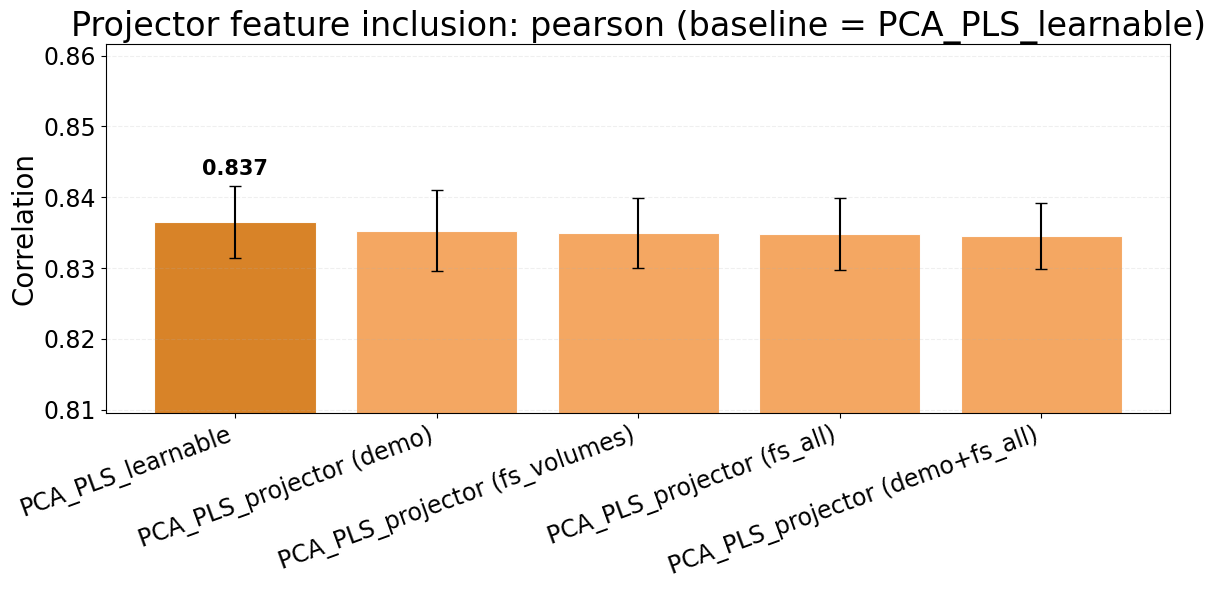

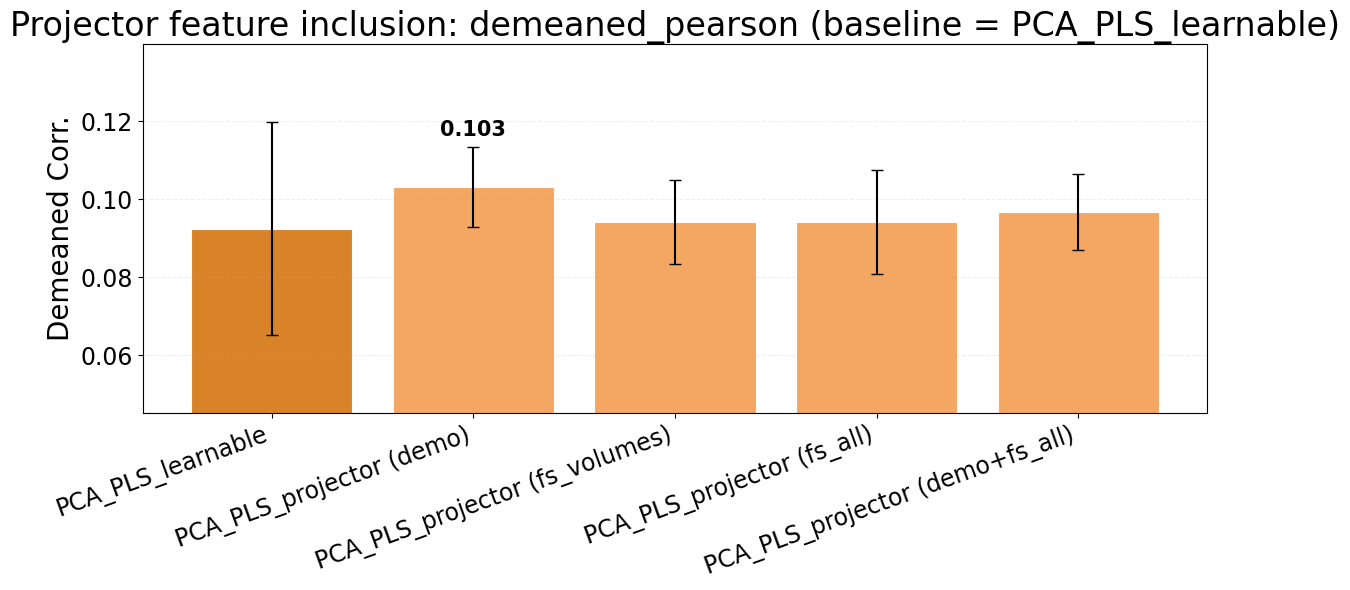

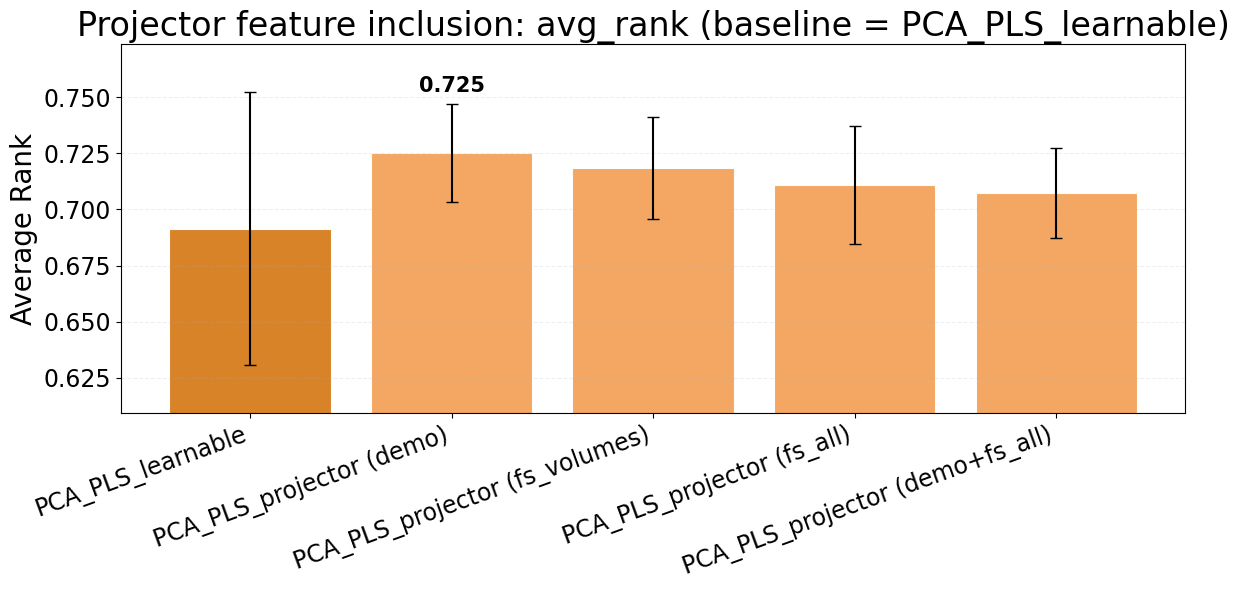

In [55]:
projector_focus_table = build_cov_dl_summary_table(
    seed_df=seed_df,
    row_specs=PROJECTOR_FOCUS_ROW_SPECS,
    metrics=METRICS,
    metric_labels=METRIC_LABELS,
    count_col='seeds',
    n_label='n',
)

display(projector_focus_table)

for metric in ['pearson', 'demeaned_pearson', 'avg_rank']:
    fig, ax, plot_df = plot_cov_dl_metric_bars(
        seed_df=seed_df,
        row_specs=PROJECTOR_FOCUS_ROW_SPECS,
        metric=metric,
        title=f"Projector feature inclusion: {metric} (baseline = PCA_PLS_learnable)",
    )
    display(plot_df)


## 5. Global Model Comparison

This section compares the selected global model set against a single projector variant, controlled by `BEST_PROJECTOR_COV_TYPE`.
The figure follows the compact schematic layout: model names on the y axis, with horizontal panels for correlation, demeaned correlation, average rank, and top-1 accuracy.


,plot_label,model,color,pearson_mean,pearson_std,demeaned_pearson_mean,demeaned_pearson_std,avg_rank_mean,avg_rank_std,top1_acc_mean,top1_acc_std
0,Krakencoder,Krakencoder_precomputed,#9467BD,0.8325,0.0040,0.0850,0.0045,0.7485,0.0124,0.0554,0.0107
1,PCA_PLS_learnable,CrossModal_PCA_PLS_learnable,#D67C1C,0.8365,0.0051,0.0924,0.0272,0.6915,0.0608,0.0333,0.0203
2,PCA_PLS_projector (demo),CrossModal_PCA_PLS_CovProjector,#F4A259,0.8353,0.0057,0.1031,0.0103,0.7252,0.0220,0.0369,0.0135
3,"MLP (Sarwar, 2021)",Sarwar2020MLP,#B07AA1,0.8204,0.0129,0.0636,0.0118,0.6376,0.0233,0.0302,0.0127
4,"GNN (Chen, 2024)",Chen2024GCN,#59A14F,0.7487,0.0181,0.0186,0.0051,0.5688,0.0148,0.0063,0.0040
5,Nodal GNN,NodalGNN,#17BECF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


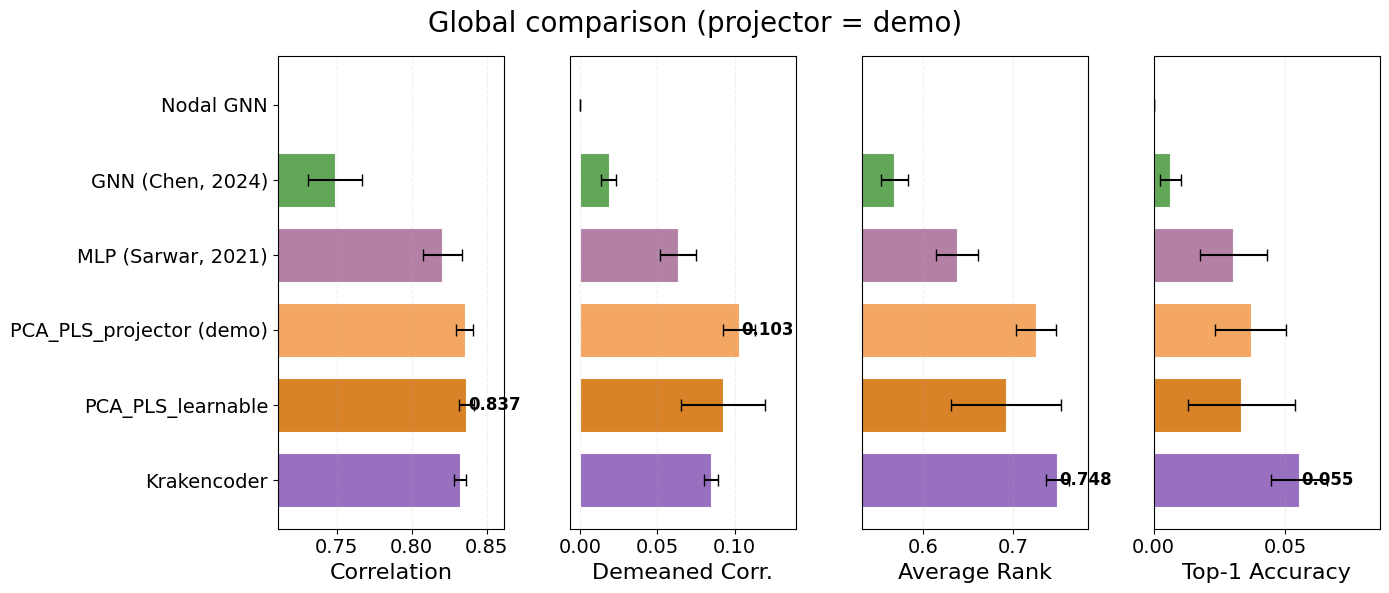

In [56]:
fig, axes, global_plot_df = plot_cov_dl_global_metric_panels(
    seed_df=seed_df,
    row_specs=GLOBAL_COMPARE_ROW_SPECS,
    metrics=['pearson', 'demeaned_pearson', 'avg_rank', 'top1_acc'],
    title=f"Global comparison (projector = {BEST_PROJECTOR_COV_TYPE})",
)

display(global_plot_df)
